In [1]:
!pip install wordcloud
!pip install pandas

In [9]:
import pandas as pd
import re
import json
import requests

# 데이터 로드
file_path = '/content/drive/MyDrive/reviewlens/computeracc.xlsx'
text_data = pd.read_excel(file_path)

reviews = text_data['상품평']
product_names = text_data['상품명'].astype(str).tolist()  # 제품명 컬럼 추가
review_list = reviews.astype(str).tolist()

# 불용어 정의 (예시)
stopwords = ['의','가','이','은','는','을','를','에','에게','께서','에서','으로','부터','까지','와','과','도','만','이나','다','는데','라고','하는','하고','하지만','그리고','그러나','또는','혹은','아니면','하지만','그렇지만','그래도','하지만','그래도','하면서','하면','한다면','할','수','있다면','있으면','없다면','없으면','이다','있습니다','없습니다','입니다','아닙니다','하는','할','수','있는','없는','것입니다','것이','것을','것이기','때문에','때문이다','때문이라고','때문이라면','때문이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는']


# 전처리 함수 정의
def preprocess(review_list):

    for review in review_list:
        review = re.sub(r'[^가-힣a-zA-Z0-9\s]', '', review)  # 한글, 영어, 숫자, 공백만 남김

        tokens = review.split() #공백 기준으로 토큰화
        filtered_tokens = [word for word in tokens if word not in stopwords] #불용어들 빼고 리스트에 다시 저장

        processed_reviews.append(' '.join(filtered_tokens)) #필터링된 토큰들을 다시 문자열로 결합하여 저장
    return processed_reviews

# 전처리 실행
preprocessed_reviews = preprocess(review_list)
reviews_json_test = {str(i+1): review for i, review in enumerate(preprocessed_reviews[:300])}

# 네이버 API 설정
url = "https://naveropenapi.apigw.ntruss.com/sentiment-analysis/v1/analyze"
headers = {
    "X-NCP-APIGW-API-KEY-ID": "du3ih5txai",
    "X-NCP-APIGW-API-KEY": "ec4m24HVhH9Zqf2kNRMjUmahTFxngIv8iCaeIqu0",
    "Content-Type": "application/json"
}


# 감정분석 실행 및 결과 저장
for review_id, review_text in reviews_json_test.items():
    data = {
        "content": review_text
    }

    try:
        response = requests.post(url, headers=headers, data=json.dumps(data))

        if response.status_code == 200:
            result = response.json()

            # 결과 포맷팅
            summary = {
                "product_name": product_names[int(review_id)-1],  # 제품명
                "original_content": review_text,  # 원본 리뷰
                "combined_content": review_text.replace('\n', ' ').strip(),  # 줄바꿈 제
                "sentiment_result": result['document']['sentiment']  # 감정분석 결과
            }
            summary_list.append(summary)
            # print(f"리뷰 {review_id} 처리 완료")

        else:
            print(f"에러 발생: {response.status_code}, {response.text}")

    except Exception as e:
        print(f"리뷰 {review_id} 처리 중 오류 발생: {str(e)}")
        continue

# 결과를 JSON 파일로 저장
with open('sentiment_results.json', 'w', encoding='utf-8') as f:
    json.dump(summary_list, f, ensure_ascii=False, indent=2)

print("\n처리 완료된 리뷰 수:", len(summary_list))
print("\n저장된 결과 샘플:")
print(json.dumps(summary_list[0], ensure_ascii=False, indent=2))


처리 완료된 리뷰 수: 300

저장된 결과 샘플:
{
  "product_name": "○○ 긴 가죽 마우스패드 롱마우스매트",
  "original_content": "상당히 크네요 아무튼 튼튼해서 오래 쓰겠어요 처음엔 커서가 마구 움직여서 당황했는데 자세히 보니 미세하게 조금 더 매트한 면이 있기에 뒤집었더니 안정되더라구요 잘 쓰고",
  "combined_content": "상당히 크네요 아무튼 튼튼해서 오래 쓰겠어요 처음엔 커서가 마구 움직여서 당황했는데 자세히 보니 미세하게 조금 더 매트한 면이 있기에 뒤집었더니 안정되더라구요 잘 쓰고",
  "sentiment_result": "positive"
}


In [8]:
import pandas as pd
import re
import json
import requests

# 데이터 로드
file_path = '/content/drive/MyDrive/reviewlens/computeracc.xlsx'
text_data = pd.read_excel(file_path)

reviews = text_data['상품평']
product_names = text_data['상품명'].astype(str).tolist()  # 제품명 컬럼 추가
review_list = reviews.astype(str).tolist()

# 불용어 정의 (예시)
stopwords = ['의','가','이','은','는','을','를','에','에게','께서','에서','으로','부터','까지','와','과','도','만','이나','다','는데','라고','하는','하고','하지만','그리고','그러나','또는','혹은','아니면','하지만','그렇지만','그래도','하지만','그래도','하면서','하면','한다면','할','수','있다면','있으면','없다면','없으면','이다','있습니다','없습니다','입니다','아닙니다','하는','할','수','있는','없는','것입니다','것이','것을','것이기','때문에','때문이다','때문이라고','때문이라면','때문이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는']


processed_reviews = []
summary_list = []
# 전처리 함수 정의
def preprocess(review_list):

    for review in review_list:
        review = re.sub(r'[^가-힣a-zA-Z0-9\s]', '', review)  # 한글, 영어, 숫자, 공백만 남김

        tokens = review.split() #공백 기준으로 토큰화
        filtered_tokens = [word for word in tokens if word not in stopwords] #불용어들 빼고 리스트에 다시 저장

        processed_reviews.append(' '.join(filtered_tokens)) #필터링된 토큰들을 다시 문자열로 결합하여 저장
    return processed_reviews

# 전처리 실행
preprocessed_reviews = preprocess(review_list)
reviews_json_test = {str(i+1): review for i, review in enumerate(preprocessed_reviews[300:600])}

# 네이버 API 설정
url = "https://naveropenapi.apigw.ntruss.com/sentiment-analysis/v1/analyze"
headers = {
    "X-NCP-APIGW-API-KEY-ID": "du3ih5txai",
    "X-NCP-APIGW-API-KEY": "ec4m24HVhH9Zqf2kNRMjUmahTFxngIv8iCaeIqu0",
    "Content-Type": "application/json"
}

# 결과를 저장할 리스트 초기화


# 감정분석 실행 및 결과 저장
for review_id, review_text in reviews_json_test.items():
    data = {
        "content": review_text
    }

    try:
        response = requests.post(url, headers=headers, data=json.dumps(data))

        if response.status_code == 200:
            result = response.json()

            # 결과 포맷팅
            summary = {
                "product_name": product_names[int(review_id)-1],  # 제품명
                "original_content": review_text,  # 원본 리뷰
                "combined_content": review_text.replace('\n', ' ').strip(),  # 줄바꿈 제
                "sentiment_result": result['document']['sentiment']  # 감정분석 결과
            }
            summary_list.append(summary)
            # print(f"리뷰 {review_id} 처리 완료")

        else:
            print(f"에러 발생: {response.status_code}, {response.text}")

    except Exception as e:
        print(f"리뷰 {review_id} 처리 중 오류 발생: {str(e)}")
        continue

# 결과를 JSON 파일로 저장
with open('sentiment_results.json', 'w', encoding='utf-8') as f:
    json.dump(summary_list, f, ensure_ascii=False, indent=2)

print("\n처리 완료된 리뷰 수:", len(summary_list))
print("\n저장된 결과 샘플:")
print(json.dumps(summary_list[0], ensure_ascii=False, indent=2))


처리 완료된 리뷰 수: 300

저장된 결과 샘플:
{
  "product_name": "○○ 긴 가죽 마우스패드 롱마우스매트",
  "original_content": "노트북 핸드폰에 설정하는게 좀 헷갈렸지만 사진 출력도 잘 되고 맘에 듭니다 고장없이 오래 사용할수 있음 좋겠네요",
  "combined_content": "노트북 핸드폰에 설정하는게 좀 헷갈렸지만 사진 출력도 잘 되고 맘에 듭니다 고장없이 오래 사용할수 있음 좋겠네요",
  "sentiment_result": "positive"
}


In [10]:
import pandas as pd
import re
import json
import requests

# 데이터 로드
file_path = '/content/drive/MyDrive/reviewlens/computeracc.xlsx'
text_data = pd.read_excel(file_path)

reviews = text_data['상품평']
product_names = text_data['상품명'].astype(str).tolist()  # 제품명 컬럼 추가
review_list = reviews.astype(str).tolist()

# 불용어 정의 (예시)
stopwords = ['의','가','이','은','는','을','를','에','에게','께서','에서','으로','부터','까지','와','과','도','만','이나','다','는데','라고','하는','하고','하지만','그리고','그러나','또는','혹은','아니면','하지만','그렇지만','그래도','하지만','그래도','하면서','하면','한다면','할','수','있다면','있으면','없다면','없으면','이다','있습니다','없습니다','입니다','아닙니다','하는','할','수','있는','없는','것입니다','것이','것을','것이기','때문에','때문이다','때문이라고','때문이라면','때문이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는']


# 전처리 함수 정의
def preprocess(review_list):

    for review in review_list:
        review = re.sub(r'[^가-힣a-zA-Z0-9\s]', '', review)  # 한글, 영어, 숫자, 공백만 남김

        tokens = review.split() #공백 기준으로 토큰화
        filtered_tokens = [word for word in tokens if word not in stopwords] #불용어들 빼고 리스트에 다시 저장

        processed_reviews.append(' '.join(filtered_tokens)) #필터링된 토큰들을 다시 문자열로 결합하여 저장
    return processed_reviews

# 전처리 실행
preprocessed_reviews = preprocess(review_list)
reviews_json_test = {str(i+1): review for i, review in enumerate(preprocessed_reviews[600:1000])}

# 네이버 API 설정
url = "https://naveropenapi.apigw.ntruss.com/sentiment-analysis/v1/analyze"
headers = {
    "X-NCP-APIGW-API-KEY-ID": "du3ih5txai",
    "X-NCP-APIGW-API-KEY": "ec4m24HVhH9Zqf2kNRMjUmahTFxngIv8iCaeIqu0",
    "Content-Type": "application/json"
}

# 결과를 저장할 리스트 초기화


# 감정분석 실행 및 결과 저장
for review_id, review_text in reviews_json_test.items():
    data = {
        "content": review_text
    }

    try:
        response = requests.post(url, headers=headers, data=json.dumps(data))

        if response.status_code == 200:
            result = response.json()

            # 결과 포맷팅
            summary = {
                "product_name": product_names[int(review_id)-1],  # 제품명
                "original_content": review_text,  # 원본 리뷰
                "combined_content": review_text.replace('\n', ' ').strip(),  # 줄바꿈 제
                "sentiment_result": result['document']['sentiment']  # 감정분석 결과
            }
            summary_list.append(summary)
            # print(f"리뷰 {review_id} 처리 완료")

        else:
            print(f"에러 발생: {response.status_code}, {response.text}")

    except Exception as e:
        print(f"리뷰 {review_id} 처리 중 오류 발생: {str(e)}")
        continue

# 결과를 JSON 파일로 저장
with open('sentiment_results.json', 'w', encoding='utf-8') as f:
    json.dump(summary_list, f, ensure_ascii=False, indent=2)

print("\n처리 완료된 리뷰 수:", len(summary_list))
print("\n저장된 결과 샘플:")
print(json.dumps(summary_list[0], ensure_ascii=False, indent=2))


처리 완료된 리뷰 수: 700

저장된 결과 샘플:
{
  "product_name": "○○ 긴 가죽 마우스패드 롱마우스매트",
  "original_content": "상당히 크네요 아무튼 튼튼해서 오래 쓰겠어요 처음엔 커서가 마구 움직여서 당황했는데 자세히 보니 미세하게 조금 더 매트한 면이 있기에 뒤집었더니 안정되더라구요 잘 쓰고",
  "combined_content": "상당히 크네요 아무튼 튼튼해서 오래 쓰겠어요 처음엔 커서가 마구 움직여서 당황했는데 자세히 보니 미세하게 조금 더 매트한 면이 있기에 뒤집었더니 안정되더라구요 잘 쓰고",
  "sentiment_result": "positive"
}


In [11]:
import pandas as pd
import re
import json
import requests

# 데이터 로드
file_path = '/content/drive/MyDrive/reviewlens/computeracc.xlsx'
text_data = pd.read_excel(file_path)

reviews = text_data['상품평']
product_names = text_data['상품명'].astype(str).tolist()  # 제품명 컬럼 추가
review_list = reviews.astype(str).tolist()

# 불용어 정의 (예시)
stopwords = ['의','가','이','은','는','을','를','에','에게','께서','에서','으로','부터','까지','와','과','도','만','이나','다','는데','라고','하는','하고','하지만','그리고','그러나','또는','혹은','아니면','하지만','그렇지만','그래도','하지만','그래도','하면서','하면','한다면','할','수','있다면','있으면','없다면','없으면','이다','있습니다','없습니다','입니다','아닙니다','하는','할','수','있는','없는','것입니다','것이','것을','것이기','때문에','때문이다','때문이라고','때문이라면','때문이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는']


# 전처리 함수 정의
def preprocess(review_list):

    for review in review_list:
        review = re.sub(r'[^가-힣a-zA-Z0-9\s]', '', review)  # 한글, 영어, 숫자, 공백만 남김

        tokens = review.split() #공백 기준으로 토큰화
        filtered_tokens = [word for word in tokens if word not in stopwords] #불용어들 빼고 리스트에 다시 저장

        processed_reviews.append(' '.join(filtered_tokens)) #필터링된 토큰들을 다시 문자열로 결합하여 저장
    return processed_reviews

# 전처리 실행
preprocessed_reviews = preprocess(review_list)
reviews_json_test = {str(i+1): review for i, review in enumerate(preprocessed_reviews[1000:1400])}

# 네이버 API 설정
url = "https://naveropenapi.apigw.ntruss.com/sentiment-analysis/v1/analyze"
headers = {
    "X-NCP-APIGW-API-KEY-ID": "du3ih5txai",
    "X-NCP-APIGW-API-KEY": "ec4m24HVhH9Zqf2kNRMjUmahTFxngIv8iCaeIqu0",
    "Content-Type": "application/json"
}

# 결과를 저장할 리스트 초기화


# 감정분석 실행 및 결과 저장
for review_id, review_text in reviews_json_test.items():
    data = {
        "content": review_text
    }

    try:
        response = requests.post(url, headers=headers, data=json.dumps(data))

        if response.status_code == 200:
            result = response.json()

            # 결과 포맷팅
            summary = {
                "product_name": product_names[int(review_id)-1],  # 제품명
                "original_content": review_text,  # 원본 리뷰
                "combined_content": review_text.replace('\n', ' ').strip(),  # 줄바꿈 제
                "sentiment_result": result['document']['sentiment']  # 감정분석 결과
            }
            summary_list.append(summary)
            # print(f"리뷰 {review_id} 처리 완료")

        else:
            print(f"에러 발생: {response.status_code}, {response.text}")

    except Exception as e:
        print(f"리뷰 {review_id} 처리 중 오류 발생: {str(e)}")
        continue

# 결과를 JSON 파일로 저장
with open('sentiment_results.json', 'w', encoding='utf-8') as f:
    json.dump(summary_list, f, ensure_ascii=False, indent=2)

print("\n처리 완료된 리뷰 수:", len(summary_list))
print("\n저장된 결과 샘플:")
print(json.dumps(summary_list[0], ensure_ascii=False, indent=2))


처리 완료된 리뷰 수: 400

저장된 결과 샘플:
{
  "product_name": "○○ 긴 가죽 마우스패드 롱마우스매트",
  "original_content": "저렴한 가격에잘 구매했어요 가성비 굿 이쁜 디자인까지 만족입니다",
  "combined_content": "저렴한 가격에잘 구매했어요 가성비 굿 이쁜 디자인까지 만족입니다",
  "sentiment_result": "positive"
}


In [1]:
import pandas as pd
import re
import json
import requests

# 데이터 로드
file_path = '/content/drive/MyDrive/reviewlens/computeracc.xlsx'
text_data = pd.read_excel(file_path)

reviews = text_data['상품평']
product_names = text_data['상품명'].astype(str).tolist()  # 제품명 컬럼 추가
review_list = reviews.astype(str).tolist()

# 불용어 정의 (예시)
stopwords = ['의','가','이','은','는','을','를','에','에게','께서','에서','으로','부터','까지','와','과','도','만','이나','다','는데','라고','하는','하고','하지만','그리고','그러나','또는','혹은','아니면','하지만','그렇지만','그래도','하지만','그래도','하면서','하면','한다면','할','수','있다면','있으면','없다면','없으면','이다','있습니다','없습니다','입니다','아닙니다','하는','할','수','있는','없는','것입니다','것이','것을','것이기','때문에','때문이다','때문이라고','때문이라면','때문이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는']


processed_reviews = []
summary_list = []
# 전처리 함수 정의
def preprocess(review_list):

    for review in review_list:
        review = re.sub(r'[^가-힣a-zA-Z0-9\s]', '', review)  # 한글, 영어, 숫자, 공백만 남김

        tokens = review.split() #공백 기준으로 토큰화
        filtered_tokens = [word for word in tokens if word not in stopwords] #불용어들 빼고 리스트에 다시 저장

        processed_reviews.append(' '.join(filtered_tokens)) #필터링된 토큰들을 다시 문자열로 결합하여 저장
    return processed_reviews

# 전처리 실행
preprocessed_reviews = preprocess(review_list)
reviews_json_test = {str(i+1): review for i, review in enumerate(preprocessed_reviews[0:300])}

# 네이버 API 설정
url = "https://naveropenapi.apigw.ntruss.com/sentiment-analysis/v1/analyze"
headers = {
    "X-NCP-APIGW-API-KEY-ID": "2ujfm71vps",
    "X-NCP-APIGW-API-KEY": "vVBBSTvLA2WWmOJm5oSrftBdspSLF9RcCHBU5z8d",
    "Content-Type": "application/json"
}

# 결과를 저장할 리스트 초기화


# 감정분석 실행 및 결과 저장
for review_id, review_text in reviews_json_test.items():
    data = {
        "content": review_text
    }

    try:
        response = requests.post(url, headers=headers, data=json.dumps(data))

        if response.status_code == 200:
            result = response.json()

            # 결과 포맷팅
            summary = {
                "product_name": product_names[int(review_id)-1],  # 제품명
                "original_content": review_text,  # 원본 리뷰
                "combined_content": review_text.replace('\n', ' ').strip(),  # 줄바꿈 제
                "sentiment_result": result['document']['sentiment']  # 감정분석 결과
            }
            summary_list.append(summary)
            # print(f"리뷰 {review_id} 처리 완료")

        else:
            print(f"에러 발생: {response.status_code}, {response.text}")

    except Exception as e:
        print(f"리뷰 {review_id} 처리 중 오류 발생: {str(e)}")
        continue

# 결과를 JSON 파일로 저장
with open('sentiment_results.json', 'w', encoding='utf-8') as f:
    json.dump(summary_list, f, ensure_ascii=False, indent=2)

print("\n처리 완료된 리뷰 수:", len(summary_list))
print("\n저장된 결과 샘플:")
print(json.dumps(summary_list[0], ensure_ascii=False, indent=2))


처리 완료된 리뷰 수: 300

저장된 결과 샘플:
{
  "product_name": "○○ 긴 가죽 마우스패드 롱마우스매트",
  "original_content": "상당히 크네요 아무튼 튼튼해서 오래 쓰겠어요 처음엔 커서가 마구 움직여서 당황했는데 자세히 보니 미세하게 조금 더 매트한 면이 있기에 뒤집었더니 안정되더라구요 잘 쓰고",
  "combined_content": "상당히 크네요 아무튼 튼튼해서 오래 쓰겠어요 처음엔 커서가 마구 움직여서 당황했는데 자세히 보니 미세하게 조금 더 매트한 면이 있기에 뒤집었더니 안정되더라구요 잘 쓰고",
  "sentiment_result": "positive"
}


In [2]:
import pandas as pd
import re
import json
import requests

# 데이터 로드
file_path = '/content/drive/MyDrive/reviewlens/computeracc.xlsx'
text_data = pd.read_excel(file_path)

reviews = text_data['상품평']
product_names = text_data['상품명'].astype(str).tolist()  # 제품명 컬럼 추가
review_list = reviews.astype(str).tolist()

# 불용어 정의 (예시)
stopwords = ['의','가','이','은','는','을','를','에','에게','께서','에서','으로','부터','까지','와','과','도','만','이나','다','는데','라고','하는','하고','하지만','그리고','그러나','또는','혹은','아니면','하지만','그렇지만','그래도','하지만','그래도','하면서','하면','한다면','할','수','있다면','있으면','없다면','없으면','이다','있습니다','없습니다','입니다','아닙니다','하는','할','수','있는','없는','것입니다','것이','것을','것이기','때문에','때문이다','때문이라고','때문이라면','때문이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는']



# 전처리 함수 정의
def preprocess(review_list):

    for review in review_list:
        review = re.sub(r'[^가-힣a-zA-Z0-9\s]', '', review)  # 한글, 영어, 숫자, 공백만 남김

        tokens = review.split() #공백 기준으로 토큰화
        filtered_tokens = [word for word in tokens if word not in stopwords] #불용어들 빼고 리스트에 다시 저장

        processed_reviews.append(' '.join(filtered_tokens)) #필터링된 토큰들을 다시 문자열로 결합하여 저장
    return processed_reviews

# 전처리 실행
preprocessed_reviews = preprocess(review_list)
reviews_json_test = {str(i+1): review for i, review in enumerate(preprocessed_reviews[300:600])}

# 네이버 API 설정
url = "https://naveropenapi.apigw.ntruss.com/sentiment-analysis/v1/analyze"
headers = {
    "X-NCP-APIGW-API-KEY-ID": "2ujfm71vps",
    "X-NCP-APIGW-API-KEY": "vVBBSTvLA2WWmOJm5oSrftBdspSLF9RcCHBU5z8d",
    "Content-Type": "application/json"
}

# 결과를 저장할 리스트 초기화


# 감정분석 실행 및 결과 저장
for review_id, review_text in reviews_json_test.items():
    data = {
        "content": review_text
    }

    try:
        response = requests.post(url, headers=headers, data=json.dumps(data))

        if response.status_code == 200:
            result = response.json()

            # 결과 포맷팅
            summary = {
                "product_name": product_names[int(review_id)-1],  # 제품명
                "original_content": review_text,  # 원본 리뷰
                "combined_content": review_text.replace('\n', ' ').strip(),  # 줄바꿈 제
                "sentiment_result": result['document']['sentiment']  # 감정분석 결과
            }
            summary_list.append(summary)
            # print(f"리뷰 {review_id} 처리 완료")

        else:
            print(f"에러 발생: {response.status_code}, {response.text}")

    except Exception as e:
        print(f"리뷰 {review_id} 처리 중 오류 발생: {str(e)}")
        continue

# 결과를 JSON 파일로 저장
with open('sentiment_results.json', 'w', encoding='utf-8') as f:
    json.dump(summary_list, f, ensure_ascii=False, indent=2)

print("\n처리 완료된 리뷰 수:", len(summary_list))
print("\n저장된 결과 샘플:")
print(json.dumps(summary_list[0], ensure_ascii=False, indent=2))


처리 완료된 리뷰 수: 600

저장된 결과 샘플:
{
  "product_name": "○○ 긴 가죽 마우스패드 롱마우스매트",
  "original_content": "상당히 크네요 아무튼 튼튼해서 오래 쓰겠어요 처음엔 커서가 마구 움직여서 당황했는데 자세히 보니 미세하게 조금 더 매트한 면이 있기에 뒤집었더니 안정되더라구요 잘 쓰고",
  "combined_content": "상당히 크네요 아무튼 튼튼해서 오래 쓰겠어요 처음엔 커서가 마구 움직여서 당황했는데 자세히 보니 미세하게 조금 더 매트한 면이 있기에 뒤집었더니 안정되더라구요 잘 쓰고",
  "sentiment_result": "positive"
}


In [3]:
import pandas as pd
import re
import json
import requests

# 데이터 로드
file_path = '/content/drive/MyDrive/reviewlens/computeracc.xlsx'
text_data = pd.read_excel(file_path)

reviews = text_data['상품평']
product_names = text_data['상품명'].astype(str).tolist()  # 제품명 컬럼 추가
review_list = reviews.astype(str).tolist()

# 불용어 정의 (예시)
stopwords = ['의','가','이','은','는','을','를','에','에게','께서','에서','으로','부터','까지','와','과','도','만','이나','다','는데','라고','하는','하고','하지만','그리고','그러나','또는','혹은','아니면','하지만','그렇지만','그래도','하지만','그래도','하면서','하면','한다면','할','수','있다면','있으면','없다면','없으면','이다','있습니다','없습니다','입니다','아닙니다','하는','할','수','있는','없는','것입니다','것이','것을','것이기','때문에','때문이다','때문이라고','때문이라면','때문이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는']



# 전처리 함수 정의
def preprocess(review_list):

    for review in review_list:
        review = re.sub(r'[^가-힣a-zA-Z0-9\s]', '', review)  # 한글, 영어, 숫자, 공백만 남김

        tokens = review.split() #공백 기준으로 토큰화
        filtered_tokens = [word for word in tokens if word not in stopwords] #불용어들 빼고 리스트에 다시 저장

        processed_reviews.append(' '.join(filtered_tokens)) #필터링된 토큰들을 다시 문자열로 결합하여 저장
    return processed_reviews

# 전처리 실행
preprocessed_reviews = preprocess(review_list)
reviews_json_test = {str(i+1): review for i, review in enumerate(preprocessed_reviews[600:1000])}

# 네이버 API 설정
url = "https://naveropenapi.apigw.ntruss.com/sentiment-analysis/v1/analyze"
headers = {
    "X-NCP-APIGW-API-KEY-ID": "2ujfm71vps",
    "X-NCP-APIGW-API-KEY": "vVBBSTvLA2WWmOJm5oSrftBdspSLF9RcCHBU5z8d",
    "Content-Type": "application/json"
}

# 결과를 저장할 리스트 초기화


# 감정분석 실행 및 결과 저장
for review_id, review_text in reviews_json_test.items():
    data = {
        "content": review_text
    }

    try:
        response = requests.post(url, headers=headers, data=json.dumps(data))

        if response.status_code == 200:
            result = response.json()

            # 결과 포맷팅
            summary = {
                "product_name": product_names[int(review_id)-1],  # 제품명
                "original_content": review_text,  # 원본 리뷰
                "combined_content": review_text.replace('\n', ' ').strip(),  # 줄바꿈 제
                "sentiment_result": result['document']['sentiment']  # 감정분석 결과
            }
            summary_list.append(summary)
            # print(f"리뷰 {review_id} 처리 완료")

        else:
            print(f"에러 발생: {response.status_code}, {response.text}")

    except Exception as e:
        print(f"리뷰 {review_id} 처리 중 오류 발생: {str(e)}")
        continue

# 결과를 JSON 파일로 저장
with open('sentiment_results.json', 'w', encoding='utf-8') as f:
    json.dump(summary_list, f, ensure_ascii=False, indent=2)

print("\n처리 완료된 리뷰 수:", len(summary_list))
print("\n저장된 결과 샘플:")
print(json.dumps(summary_list[0], ensure_ascii=False, indent=2))


처리 완료된 리뷰 수: 1000

저장된 결과 샘플:
{
  "product_name": "○○ 긴 가죽 마우스패드 롱마우스매트",
  "original_content": "상당히 크네요 아무튼 튼튼해서 오래 쓰겠어요 처음엔 커서가 마구 움직여서 당황했는데 자세히 보니 미세하게 조금 더 매트한 면이 있기에 뒤집었더니 안정되더라구요 잘 쓰고",
  "combined_content": "상당히 크네요 아무튼 튼튼해서 오래 쓰겠어요 처음엔 커서가 마구 움직여서 당황했는데 자세히 보니 미세하게 조금 더 매트한 면이 있기에 뒤집었더니 안정되더라구요 잘 쓰고",
  "sentiment_result": "positive"
}


In [4]:
import pandas as pd
import re
import json
import requests

# 데이터 로드
file_path = '/content/drive/MyDrive/reviewlens/computeracc.xlsx'
text_data = pd.read_excel(file_path)

reviews = text_data['상품평']
product_names = text_data['상품명'].astype(str).tolist()  # 제품명 컬럼 추가
review_list = reviews.astype(str).tolist()

# 불용어 정의 (예시)
stopwords = ['의','가','이','은','는','을','를','에','에게','께서','에서','으로','부터','까지','와','과','도','만','이나','다','는데','라고','하는','하고','하지만','그리고','그러나','또는','혹은','아니면','하지만','그렇지만','그래도','하지만','그래도','하면서','하면','한다면','할','수','있다면','있으면','없다면','없으면','이다','있습니다','없습니다','입니다','아닙니다','하는','할','수','있는','없는','것입니다','것이','것을','것이기','때문에','때문이다','때문이라고','때문이라면','때문이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는']



# 전처리 함수 정의
def preprocess(review_list):

    for review in review_list:
        review = re.sub(r'[^가-힣a-zA-Z0-9\s]', '', review)  # 한글, 영어, 숫자, 공백만 남김

        tokens = review.split() #공백 기준으로 토큰화
        filtered_tokens = [word for word in tokens if word not in stopwords] #불용어들 빼고 리스트에 다시 저장

        processed_reviews.append(' '.join(filtered_tokens)) #필터링된 토큰들을 다시 문자열로 결합하여 저장
    return processed_reviews

# 전처리 실행
preprocessed_reviews = preprocess(review_list)
reviews_json_test = {str(i+1): review for i, review in enumerate(preprocessed_reviews[1000:1400])}

# 네이버 API 설정
url = "https://naveropenapi.apigw.ntruss.com/sentiment-analysis/v1/analyze"
headers = {
    "X-NCP-APIGW-API-KEY-ID": "2ujfm71vps",
    "X-NCP-APIGW-API-KEY": "vVBBSTvLA2WWmOJm5oSrftBdspSLF9RcCHBU5z8d",
    "Content-Type": "application/json"
}

# 결과를 저장할 리스트 초기화


# 감정분석 실행 및 결과 저장
for review_id, review_text in reviews_json_test.items():
    data = {
        "content": review_text
    }

    try:
        response = requests.post(url, headers=headers, data=json.dumps(data))

        if response.status_code == 200:
            result = response.json()

            # 결과 포맷팅
            summary = {
                "product_name": product_names[int(review_id)-1],  # 제품명
                "original_content": review_text,  # 원본 리뷰
                "combined_content": review_text.replace('\n', ' ').strip(),  # 줄바꿈 제
                "sentiment_result": result['document']['sentiment']  # 감정분석 결과
            }
            summary_list.append(summary)
            # print(f"리뷰 {review_id} 처리 완료")

        else:
            print(f"에러 발생: {response.status_code}, {response.text}")

    except Exception as e:
        print(f"리뷰 {review_id} 처리 중 오류 발생: {str(e)}")
        continue

# 결과를 JSON 파일로 저장
with open('sentiment_results.json', 'w', encoding='utf-8') as f:
    json.dump(summary_list, f, ensure_ascii=False, indent=2)

print("\n처리 완료된 리뷰 수:", len(summary_list))
print("\n저장된 결과 샘플:")
print(json.dumps(summary_list[0], ensure_ascii=False, indent=2))


처리 완료된 리뷰 수: 1400

저장된 결과 샘플:
{
  "product_name": "○○ 긴 가죽 마우스패드 롱마우스매트",
  "original_content": "상당히 크네요 아무튼 튼튼해서 오래 쓰겠어요 처음엔 커서가 마구 움직여서 당황했는데 자세히 보니 미세하게 조금 더 매트한 면이 있기에 뒤집었더니 안정되더라구요 잘 쓰고",
  "combined_content": "상당히 크네요 아무튼 튼튼해서 오래 쓰겠어요 처음엔 커서가 마구 움직여서 당황했는데 자세히 보니 미세하게 조금 더 매트한 면이 있기에 뒤집었더니 안정되더라구요 잘 쓰고",
  "sentiment_result": "positive"
}


In [5]:
import pandas as pd
import re
import json
import requests

# 데이터 로드
file_path = '/content/drive/MyDrive/reviewlens/computeracc.xlsx'
text_data = pd.read_excel(file_path)

reviews = text_data['상품평']
product_names = text_data['상품명'].astype(str).tolist()  # 제품명 컬럼 추가
review_list = reviews.astype(str).tolist()

# 불용어 정의 (예시)
stopwords = ['의','가','이','은','는','을','를','에','에게','께서','에서','으로','부터','까지','와','과','도','만','이나','다','는데','라고','하는','하고','하지만','그리고','그러나','또는','혹은','아니면','하지만','그렇지만','그래도','하지만','그래도','하면서','하면','한다면','할','수','있다면','있으면','없다면','없으면','이다','있습니다','없습니다','입니다','아닙니다','하는','할','수','있는','없는','것입니다','것이','것을','것이기','때문에','때문이다','때문이라고','때문이라면','때문이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는']



# 전처리 함수 정의
def preprocess(review_list):

    for review in review_list:
        review = re.sub(r'[^가-힣a-zA-Z0-9\s]', '', review)  # 한글, 영어, 숫자, 공백만 남김

        tokens = review.split() #공백 기준으로 토큰화
        filtered_tokens = [word for word in tokens if word not in stopwords] #불용어들 빼고 리스트에 다시 저장

        processed_reviews.append(' '.join(filtered_tokens)) #필터링된 토큰들을 다시 문자열로 결합하여 저장
    return processed_reviews

# 전처리 실행
preprocessed_reviews = preprocess(review_list)
reviews_json_test = {str(i+1): review for i, review in enumerate(preprocessed_reviews[1400:1900])}

# 네이버 API 설정
url = "https://naveropenapi.apigw.ntruss.com/sentiment-analysis/v1/analyze"
headers = {
    "X-NCP-APIGW-API-KEY-ID": "2ujfm71vps",
    "X-NCP-APIGW-API-KEY": "vVBBSTvLA2WWmOJm5oSrftBdspSLF9RcCHBU5z8d",
    "Content-Type": "application/json"
}

# 결과를 저장할 리스트 초기화


# 감정분석 실행 및 결과 저장
for review_id, review_text in reviews_json_test.items():
    data = {
        "content": review_text
    }

    try:
        response = requests.post(url, headers=headers, data=json.dumps(data))

        if response.status_code == 200:
            result = response.json()

            # 결과 포맷팅
            summary = {
                "product_name": product_names[int(review_id)-1],  # 제품명
                "original_content": review_text,  # 원본 리뷰
                "combined_content": review_text.replace('\n', ' ').strip(),  # 줄바꿈 제
                "sentiment_result": result['document']['sentiment']  # 감정분석 결과
            }
            summary_list.append(summary)
            # print(f"리뷰 {review_id} 처리 완료")

        else:
            print(f"에러 발생: {response.status_code}, {response.text}")

    except Exception as e:
        print(f"리뷰 {review_id} 처리 중 오류 발생: {str(e)}")
        continue

# 결과를 JSON 파일로 저장
with open('sentiment_results.json', 'w', encoding='utf-8') as f:
    json.dump(summary_list, f, ensure_ascii=False, indent=2)

print("\n처리 완료된 리뷰 수:", len(summary_list))
print("\n저장된 결과 샘플:")
print(json.dumps(summary_list[0], ensure_ascii=False, indent=2))


처리 완료된 리뷰 수: 1900

저장된 결과 샘플:
{
  "product_name": "○○ 긴 가죽 마우스패드 롱마우스매트",
  "original_content": "상당히 크네요 아무튼 튼튼해서 오래 쓰겠어요 처음엔 커서가 마구 움직여서 당황했는데 자세히 보니 미세하게 조금 더 매트한 면이 있기에 뒤집었더니 안정되더라구요 잘 쓰고",
  "combined_content": "상당히 크네요 아무튼 튼튼해서 오래 쓰겠어요 처음엔 커서가 마구 움직여서 당황했는데 자세히 보니 미세하게 조금 더 매트한 면이 있기에 뒤집었더니 안정되더라구요 잘 쓰고",
  "sentiment_result": "positive"
}


In [6]:
import pandas as pd
import re
import json
import requests

# 데이터 로드
file_path = '/content/drive/MyDrive/reviewlens/computeracc.xlsx'
text_data = pd.read_excel(file_path)

reviews = text_data['상품평']
product_names = text_data['상품명'].astype(str).tolist()  # 제품명 컬럼 추가
review_list = reviews.astype(str).tolist()

# 불용어 정의 (예시)
stopwords = ['의','가','이','은','는','을','를','에','에게','께서','에서','으로','부터','까지','와','과','도','만','이나','다','는데','라고','하는','하고','하지만','그리고','그러나','또는','혹은','아니면','하지만','그렇지만','그래도','하지만','그래도','하면서','하면','한다면','할','수','있다면','있으면','없다면','없으면','이다','있습니다','없습니다','입니다','아닙니다','하는','할','수','있는','없는','것입니다','것이','것을','것이기','때문에','때문이다','때문이라고','때문이라면','때문이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는','것입니다','것이다','것이라고','것이라면','것이라는']



# 전처리 함수 정의
def preprocess(review_list):

    for review in review_list:
        review = re.sub(r'[^가-힣a-zA-Z0-9\s]', '', review)  # 한글, 영어, 숫자, 공백만 남김

        tokens = review.split() #공백 기준으로 토큰화
        filtered_tokens = [word for word in tokens if word not in stopwords] #불용어들 빼고 리스트에 다시 저장

        processed_reviews.append(' '.join(filtered_tokens)) #필터링된 토큰들을 다시 문자열로 결합하여 저장
    return processed_reviews

# 전처리 실행
preprocessed_reviews = preprocess(review_list)
reviews_json_test = {str(i+1): review for i, review in enumerate(preprocessed_reviews[1900:])}

# 네이버 API 설정
url = "https://naveropenapi.apigw.ntruss.com/sentiment-analysis/v1/analyze"
headers = {
    "X-NCP-APIGW-API-KEY-ID": "2ujfm71vps",
    "X-NCP-APIGW-API-KEY": "vVBBSTvLA2WWmOJm5oSrftBdspSLF9RcCHBU5z8d",
    "Content-Type": "application/json"
}

# 결과를 저장할 리스트 초기화


# 감정분석 실행 및 결과 저장
for review_id, review_text in reviews_json_test.items():
    data = {
        "content": review_text
    }

    try:
        response = requests.post(url, headers=headers, data=json.dumps(data))

        if response.status_code == 200:
            result = response.json()

            # 결과 포맷팅
            summary = {
                "product_name": product_names[int(review_id)-1],  # 제품명
                "original_content": review_text,  # 원본 리뷰
                "combined_content": review_text.replace('\n', ' ').strip(),  # 줄바꿈 제
                "sentiment_result": result['document']['sentiment']  # 감정분석 결과
            }
            summary_list.append(summary)
            # print(f"리뷰 {review_id} 처리 완료")

        else:
            print(f"에러 발생: {response.status_code}, {response.text}")

    except Exception as e:
        print(f"리뷰 {review_id} 처리 중 오류 발생: {str(e)}")
        continue

# 결과를 JSON 파일로 저장
with open('sentiment_results.json', 'w', encoding='utf-8') as f:
    json.dump(summary_list, f, ensure_ascii=False, indent=2)

print("\n처리 완료된 리뷰 수:", len(summary_list))
print("\n저장된 결과 샘플:")
print(json.dumps(summary_list[0], ensure_ascii=False, indent=2))

KeyboardInterrupt: 

In [7]:
!pip install wordcloud
# 한글 폰트 설치
!apt-get update -qq
!apt-get install fonts-nanum* -qq

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Selecting previously unselected package fonts-nanum.
(Reading database ... 123623 files and directories currently installed.)
Preparing to unpack .../fonts-nanum_20200506-1_all.deb ...
Unpacking fonts-nanum (20200506-1) ...
Selecting previously unselected package fonts-nanum-coding.
Preparing to unpack .../fonts-nanum-coding_2.5-3_all.deb ...
Unpacking fonts-nanum-coding (2.5-3) ...
Selecting previously unselected package fonts-nanum-eco.
Preparing to unpack .../fonts-nanum-eco_1.000-7_all.deb ...
Unpacking fonts-nanum-eco (1.000-7) ...
Selecting previously unselected package fonts-nanum-extra.
Preparing to unpack .../fonts-nanum-extra_20200506-1_all.deb ...
Unpacking fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum-extra (20200506-1) ...
Setting up fonts-nanum (20200506-1) ...
Setting up fo


긍정적인 리뷰 워드클라우드:


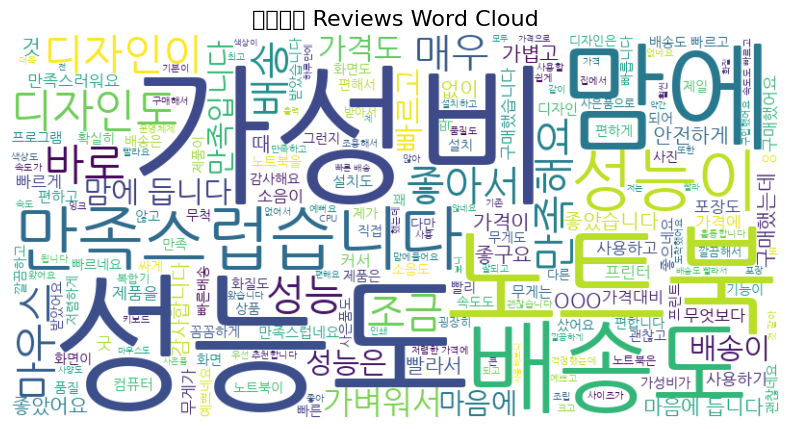


부정적인 리뷰 워드클라우드:


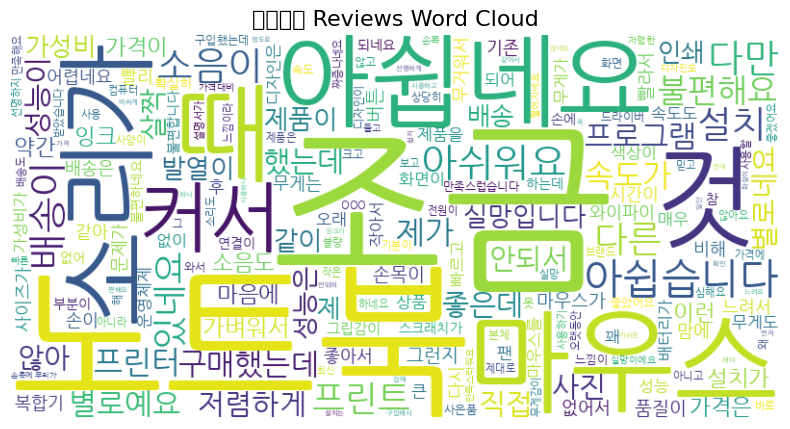


중립적인 리뷰가 없습니다.


In [17]:
import pandas as pd
import re
import json
import requests
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 긍정적인 리뷰만 필터링
def filter_positive_reviews(results):
    positive_reviews = []
    for result in results:
        if isinstance(result, dict) and result.get("sentiment_result") == "positive":  # 키 이름 수정
            positive_reviews.append(result["combined_content"])
    return positive_reviews

# 부정적인 리뷰만 필터링
def filter_negative_reviews(results):
    negative_reviews = []
    for result in results:
        if isinstance(result, dict) and result.get("sentiment_result") == "negative":  # 키 이름 수정
            negative_reviews.append(result["combined_content"])
    return negative_reviews

# 중립적인 리뷰만 필터링
def filter_neutral_reviews(results):
    neutral_reviews = []
    for result in results:
        if isinstance(result, dict) and result.get("sentiment_result") == "neutral":  # 키 이름 수정
            neutral_reviews.append(result["combined_content"])
    return neutral_reviews

# 워드 클라우드 생성 함수
def generate_wordcloud(text, title=''):
    if not text:  # 텍스트가 비어있는 경우 처리
        print(f"{title}: 텍스트가 없습니다.")
        return

    wordcloud = WordCloud(
        font_path='/content/NanumGothic.ttf',  # 폰트 경로 추가
        width=800,
        height=400,
        background_color='white'
    ).generate(text)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.title(title, fontsize=16)
    plt.axis('off')
    plt.show()

# 긍정적/부정적 워드클라우드 생성 함수
def generate_sentiment_wordclouds(results):
    if not results:  # 결과가 비어있는 경우 처리
        print("분석 결과가 없습니다.")
        return

    # 불용어 정의
    wordcloud_stopword = ['좋아요', '좋고', '잘', '많이', '너무너무', '원래', '샀는데', '같습니다',
                         '좋다길래', '괜찮아요', '있어요', '사봤어요', '보다', '요건', '그래서', '별로',
                         '따지면', '같구요', '선택했는데적당한것', '하고', '말이죠', '구매', '너무많아서',
                         '바르면', '입니다', '바르고', '광고', '첨에', '엄청', '열심히', '바르다',
                         '생각보단', '요거', '제형', '00', '얼굴에', '너무', '같아요', '없고', '없어요',
                         '좋은거', '해서', '안', '아주', '그냥', '많아', '처음', '들어있는지', '쓰고',
                         '않을거라고', '있음', '들어요', '있고', '수', '제형의', '좋은', '근데', '않을거라고','마침','합니다','갑자기','이게','가장','좋네요','이번',
                          '좀','있어서','해주셔서','진짜','않아서','완전','마음에듭니다','정말','역시','좋습니다','만족합니다','넘','생각보다','더','그런데','계속','제품','있어']

    # 감정별 리뷰 필터링
    positive_reviews = filter_positive_reviews(results)
    negative_reviews = filter_negative_reviews(results)
    neutral_reviews = filter_neutral_reviews(results)

    # 텍스트 결합 및 불용어 제거
    for reviews, sentiment in [(positive_reviews, "긍정적인"),
                             (negative_reviews, "부정적인"),
                             (neutral_reviews, "중립적인")]:
        if reviews:
            text = " ".join(reviews)
            # 불용어 제거
            filtered_words = [word for word in text.split() if word not in wordcloud_stopword]
            filtered_text = " ".join(filtered_words)

            print(f"\n{sentiment} 리뷰 워드클라우드:")
            generate_wordcloud(filtered_text, title=f'{sentiment} Reviews Word Cloud')
        else:
            print(f"\n{sentiment} 리뷰가 없습니다.")



# 워드클라우드 생성
generate_sentiment_wordclouds(summary_list)  # 변수명도 수정